In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [1]:
def european_analytic_delta(S0, K, r, sigma, T, q=0):
    d1 = (np.log(S0 / K) + (r-q + (sigma**2) / 2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def european_option_price(S0, K, T, r, sigma, q=0, option_type='call'):
    # Calculate d1 and d2
    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Call option pricing formula
    if option_type == 'call':
        option_price = S0 * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    # Put option pricing formula
    elif option_type == 'put':
        option_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * np.exp(-q * T) * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    
    return option_price

def straddle (S0, K, T, r, sigma, q=0):
    european_option_price(S0, K, T, r, sigma, q, option_type='call') + european_option_price(S0, K, T, r, sigma, q, option_type='put')

In [2]:
def european_option_time_value(S0, K, T, r, sigma, q=0, option_type='call'):

    tv = european_option_price(S0, K, T, r, sigma, q, option_type)

    iv = np.fmax(0, S0 - K) if option_type == 'call' else np.fmax(0, K - S0)

    return tv - iv

def european_option_vega(S0, K, T, r, sigma, q=0):

    # Calculate d1
    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    
    # Calculate Vega
    vega = S0 * np.exp(-q * T) * np.sqrt(T) * norm.pdf(d1)
    
    return vega

def european_option_vega_numeric(S0, K, T, r, sigma, q=0, option_type='call', h=0.001):
    
    price_up = european_option_price(S0, K, T, r, sigma + h, q, option_type)
    price_down = european_option_price(S0, K, T, r, sigma - h, q, option_type)
    
    vega = (price_up - price_down) / (2 * h)
    return vega

In [3]:
def european_option_theta_numeric(S0, K, T, r, sigma, q=0, option_type='call', h=0.001):
    
    price_up = european_option_price(S0, K, T+h, r, sigma, q, option_type)
    price_down = european_option_price(S0, K, T-h, r, sigma, q, option_type)
    
    vega = (price_up - price_down) / (2 * h)
    return vega

def european_option_gamma_numeric(S0, K, T, r, sigma, q=0, option_type='call', h=0.001):
    
    price = european_option_price(S0, K, T, r, sigma, q, option_type)
    price_up = european_option_price(S0+h, K, T, r, sigma, q, option_type)
    price_down = european_option_price(S0-h, K, T, r, sigma, q, option_type)
    
    gamma = (price_up - 2*price + price_down) / (h**2)
    return gamma

# Market and Static data

In [6]:
# Parameters
K = 100       # Strike
r = 0.05       # Risk-free interest rate
sigma = 0.2    # Volatility

# Underlying price range
S0 = np.linspace(60, 140, 300)

# Time to maturities in years
T_values = [1/12, 0.5, 1, 3]  # 1 month, 6 months, 1 year


# Price

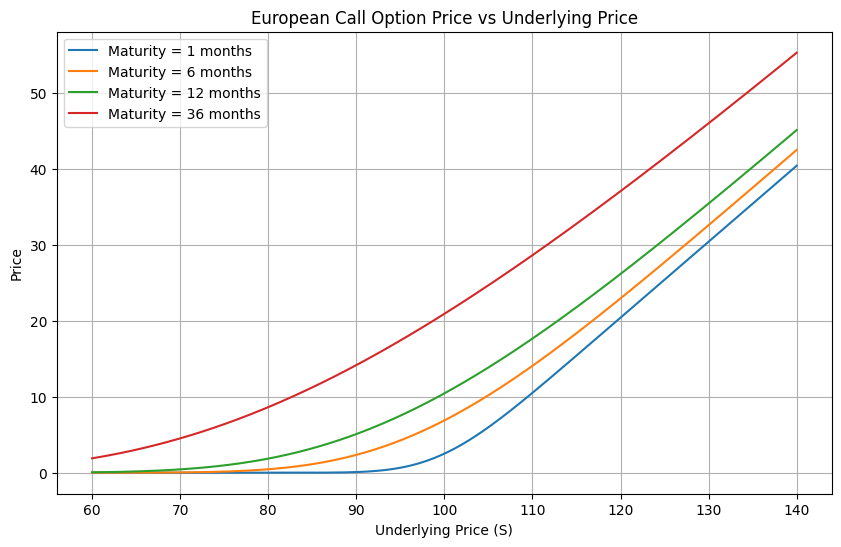

In [7]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    delta = european_option_price(S0, K, T, r, sigma)
    plt.plot(S0, delta, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title("European Call Option Price vs Underlying Price")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

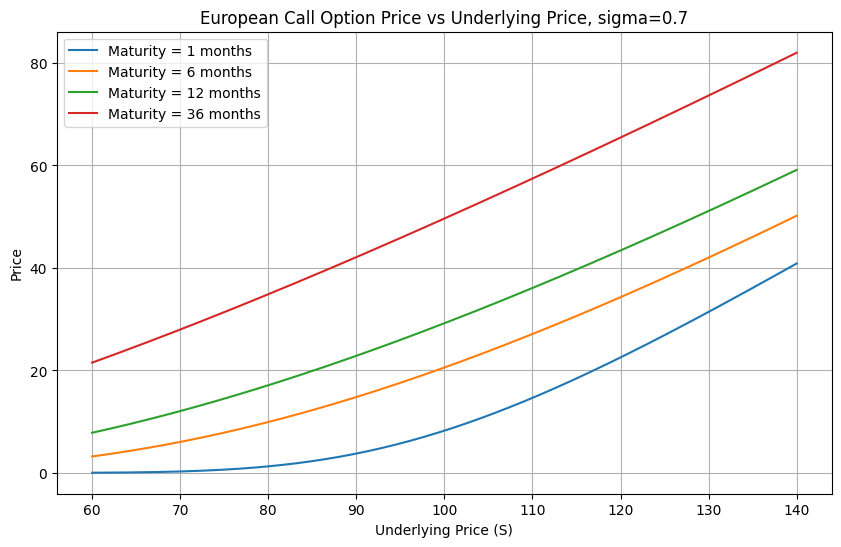

In [8]:
# Plotting
plt.figure(figsize=(10, 6))
higher_sigma = 0.7
for T in T_values:
    delta = european_option_price(S0, K, T, r, higher_sigma)
    plt.plot(S0, delta, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title(f"European Call Option Price vs Underlying Price, sigma={higher_sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# Delta

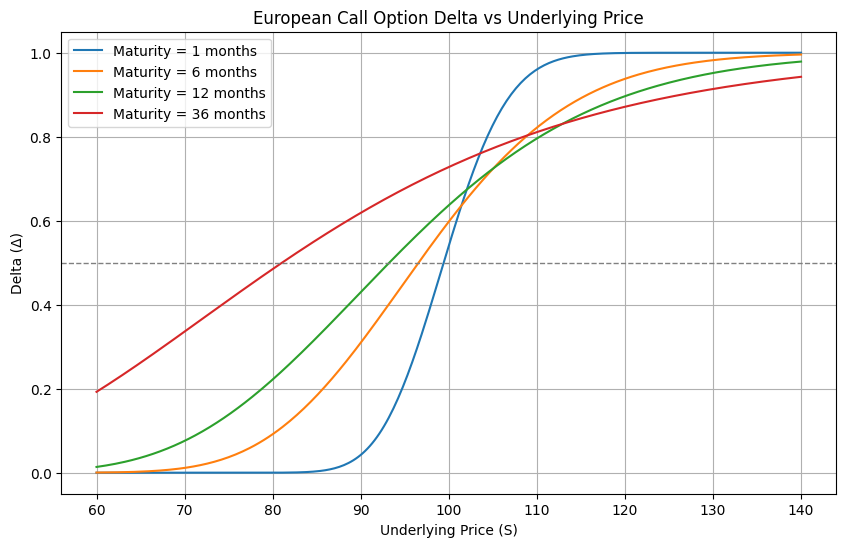

In [9]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    delta = european_analytic_delta(S0, K, r, sigma, T)
    plt.plot(S0, delta, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title("European Call Option Delta vs Underlying Price")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Delta (Δ)")
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)  # Reference line at Delta = 0.5
plt.legend()
plt.grid(True)
plt.show()

# Vega Analytic

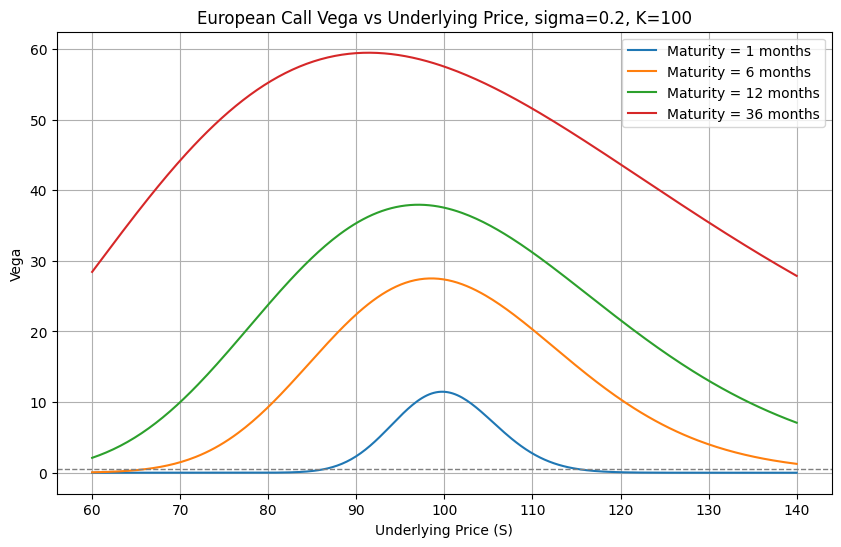

In [10]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    delta = european_option_vega(S0, K, T, r, sigma)
    plt.plot(S0, delta, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title(f"European Call Vega vs Underlying Price, sigma={sigma}, K={K}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Vega")
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)  # Reference line at Delta = 0.5
plt.legend()
plt.grid(True)
plt.show()

# Slightly OTM Call increases in price as vol increases THE MOST. High vol widens range of possible outcomes both ways - but the negative side is floored at 0. So no matter how much worse price can get, worst case scenario is 0. But positive case - unlimited.

 # Vega Numeric

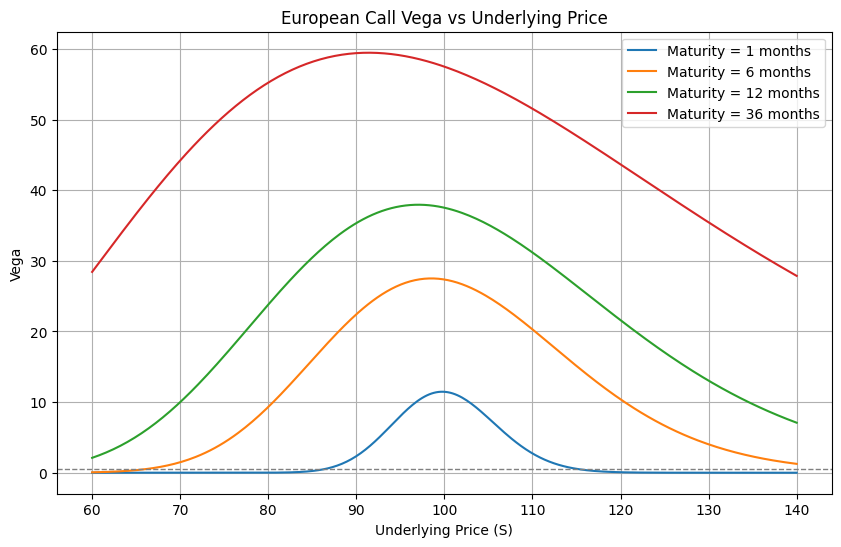

In [11]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    delta = european_option_vega_numeric(S0, K, T, r, sigma)
    plt.plot(S0, delta, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title("European Call Vega vs Underlying Price")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Vega")
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)  # Reference line at Delta = 0.5
plt.legend()
plt.grid(True)
plt.show()

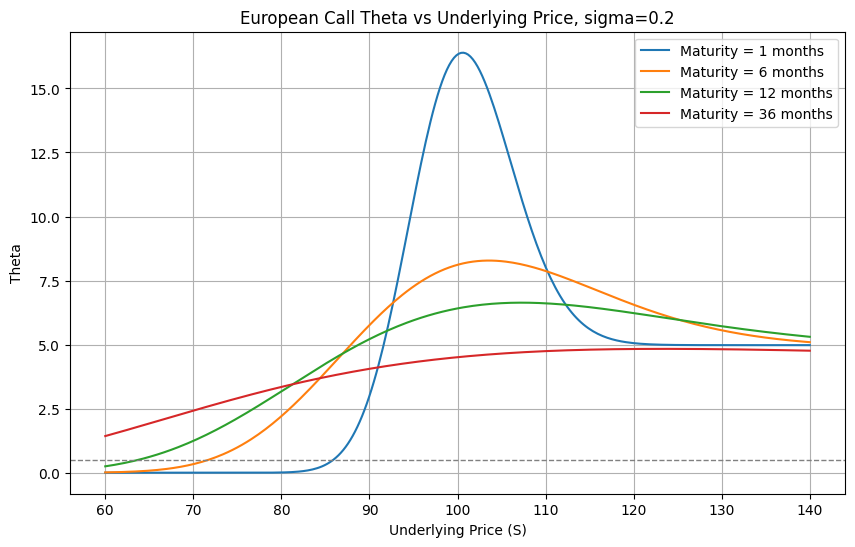

In [12]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    delta = european_option_theta_numeric(S0, K, T, r, sigma)
    plt.plot(S0, delta, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title(f"European Call Theta vs Underlying Price, sigma={sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Theta")
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)  # Reference line at Delta = 0.5
plt.legend()
plt.grid(True)
plt.show()

# As TTM increases, so does the Option Price, especially around Strike, especially around 

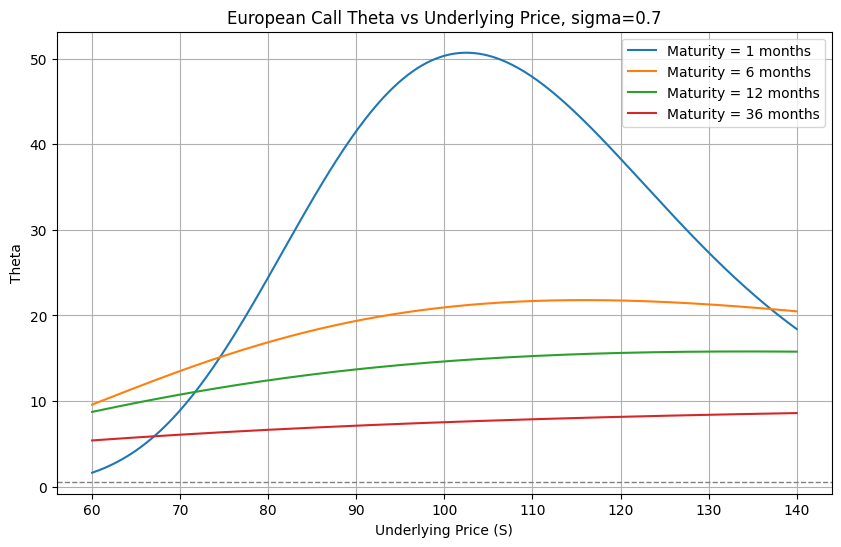

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    delta = european_option_theta_numeric(S0, K, T, r, higher_sigma)
    plt.plot(S0, delta, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title(f"European Call Theta vs Underlying Price, sigma={higher_sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Theta")
plt.legend()
plt.grid(True)
plt.show()

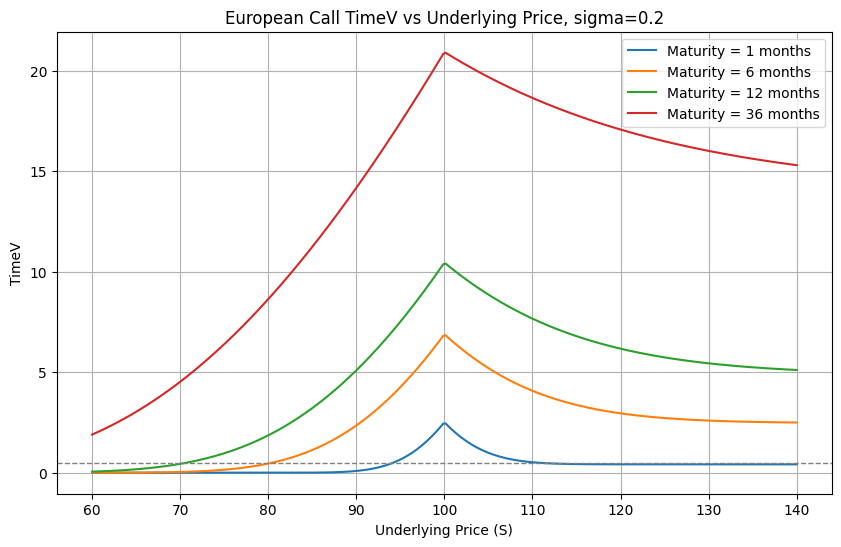

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    delta = european_option_time_value(S0, K, T, r, sigma)
    plt.plot(S0, delta, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title(f"European Call TimeV vs Underlying Price, sigma={sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("TimeV")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
import math
for T in T_values:
    print(T, "Limit: ", K*(1-math.exp(-r*T)), "; DF: ", math.exp(-r*T))

0.08333333333333333 Limit:  0.41579981548900413 ; DF:  0.99584200184511
0.5 Limit:  2.4690087971667385 ; DF:  0.9753099120283326
1 Limit:  4.877057549928598 ; DF:  0.951229424500714
3 Limit:  13.92920235749422 ; DF:  0.8607079764250578


prem=np.float64(10.450583572185565)
d=np.float64(0.6368306511756191)


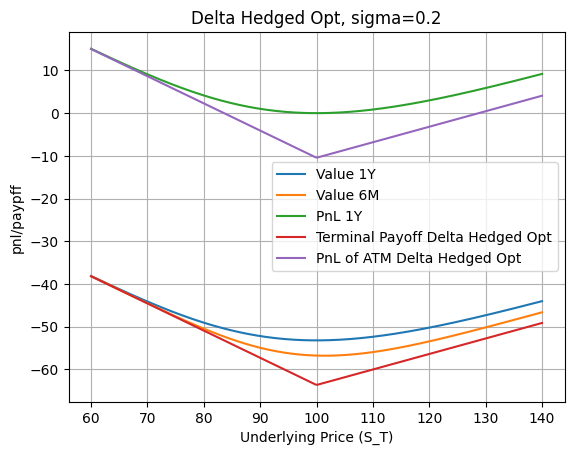

In [17]:
S_bought = 100
prem = european_option_price(S_bought, K, 1, r, sigma) 
d = european_analytic_delta(S_bought, K, r, sigma, 1) 
print(f"{prem=}")
print(f"{d=}")
hedge = d * S_bought
term_payoff = np.fmax(S0-K, 0) - d*S0
pnl = term_payoff - prem + hedge

val_1Y = european_option_price(S0, K, 1, r, sigma) -d*S0
pnl_1Y = european_option_price(S0, K, 1, r, sigma) - d*S0 + hedge - prem
val_6M = european_option_price(S0, K, 0.5, r, sigma) -d*S0

plt.plot(S0, val_1Y, label=f'Value 1Y')
plt.plot(S0, val_6M, label=f'Value 6M')
plt.plot(S0, pnl_1Y, label=f'PnL 1Y')
plt.plot(S0, term_payoff, label=f'Terminal Payoff Delta Hedged Opt')
plt.plot(S0, pnl,         label=f'PnL of ATM Delta Hedged Opt')

# Customizing plot
plt.title(f"Delta Hedged Opt, sigma={sigma}")
plt.xlabel("Underlying Price (S_T)")
plt.ylabel("pnl/paypff")
# plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)  # Reference line at Delta = 0.5
plt.legend()
plt.grid(True)
plt.show()



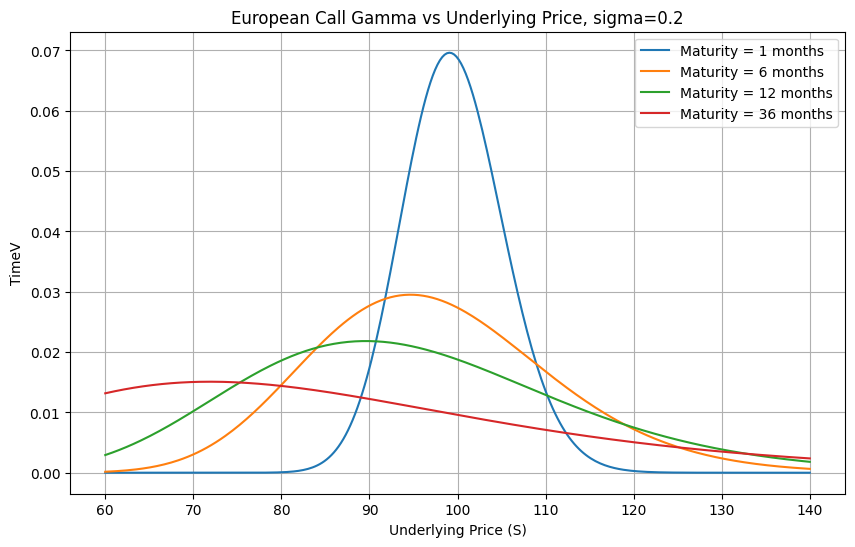

In [ ]:


# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    gamma = european_option_gamma_numeric(S0, K, T, r, sigma)
    plt.plot(S0, gamma, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title(f"European Call Gamma vs Underlying Price, sigma={sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Gamma")
plt.legend()
plt.grid(True)
plt.show()